Retail Sales Analytics

Sales Analysis Project

->Introduction
This project analyzes sales data to uncover trends in revenue by region, product category, and monthly performance.  
We will use:
- **Python** (Pandas, Numpy)
- **Matplotlib & Seaborn** (Data visualization)
- **Plotly** (Interactive charts)

---

In [3]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [4]:
## Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import ipywidgets as widgets
from ipywidgets import interact

📂 Step 1: Load & Explore Data

In [6]:
## Load Dataset
import pandas as pd
df = pd.read_csv(r"C:\Users\93sha\Downloads\sales.csv")
print(df.head())
print("Dataset shape: ")
df.shape

   OrderID  CustomerID Region     Category                      OrderDate  \
0     1001          39   East  Electronics  2023-01-01 00:00:00.000000000   
1     1002          29   East    Furniture  2023-01-02 01:26:50.050251256   
2     1003          15  South  Electronics  2023-01-03 02:53:40.100502512   
3     1004          43   West    Furniture  2023-01-04 04:20:30.150753768   
4     1005           8   West    Groceries  2023-01-05 05:47:20.201005025   

   Revenue  
0     3218  
1     2241  
2     3159  
3     4648  
4     3059  
Dataset shape: 


(200, 6)

In [7]:
## Data Cleaning
import pandas as pd

df = pd.read_csv(r"C:\Users\93sha\Downloads\sales.csv")
print(df.isnull().sum())
df = df.drop_duplicates()


## Descriptive Stats
df = pd.read_csv(r"C:\Users\93sha\Downloads\sales.csv")
print(df.describe())
print(df.info())

## Example KPIs
total_sales = df["Revenue"].sum()
total_orders = df["OrderID"].nunique()
unique_customers = df["CustomerID"].nunique()

print("Total Revenue: ", total_sales)
print("Total Orders: ", total_orders)
print("Unique Customers: ", unique_customers)

OrderID       0
CustomerID    0
Region        0
Category      0
OrderDate     0
Revenue       0
dtype: int64
           OrderID  CustomerID      Revenue
count   200.000000  200.000000   200.000000
mean   1100.500000   25.260000  2619.715000
std      57.879185   14.229716  1309.441802
min    1001.000000    1.000000   214.000000
25%    1050.750000   13.000000  1451.750000
50%    1100.500000   26.000000  2859.500000
75%    1150.250000   38.250000  3653.750000
max    1200.000000   50.000000  4949.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   OrderID     200 non-null    int64 
 1   CustomerID  200 non-null    int64 
 2   Region      200 non-null    object
 3   Category    200 non-null    object
 4   OrderDate   200 non-null    object
 5   Revenue     200 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 9.5+ KB
None
Total Revenue:  

📊 Step 2: Exploratory Data Analysis (EDA)

In [9]:
## Aggregations and Insights
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

## Revenue By Region
region_sales = df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)

## Revenue by product category
category_sales = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

## Monthly sales Trend
monthly_sales = df.groupby(df["OrderDate"].dt.to_period("M"))["Revenue"].sum().reset_index()

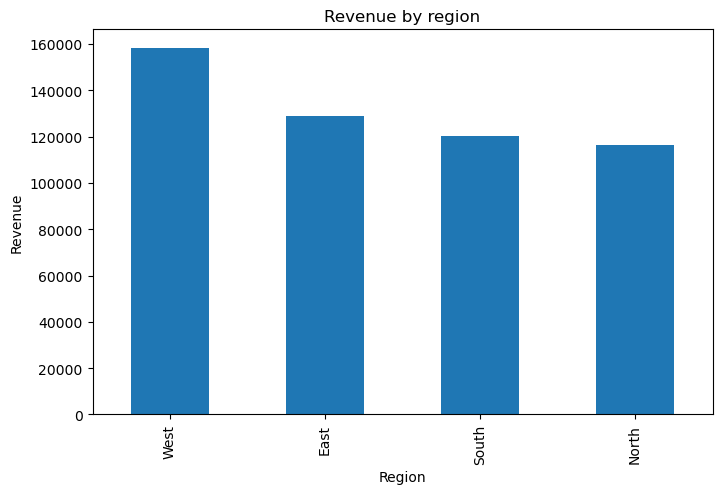

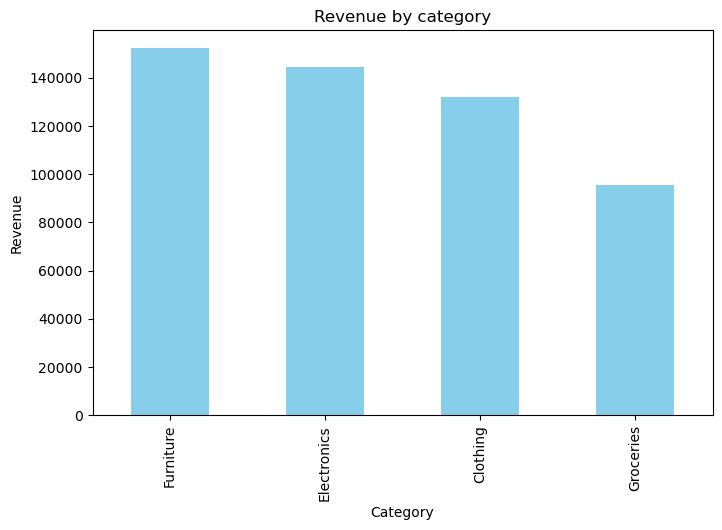

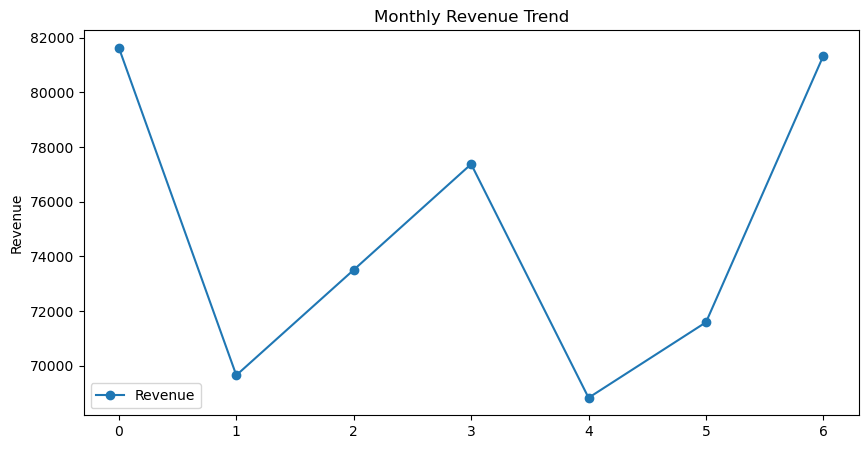

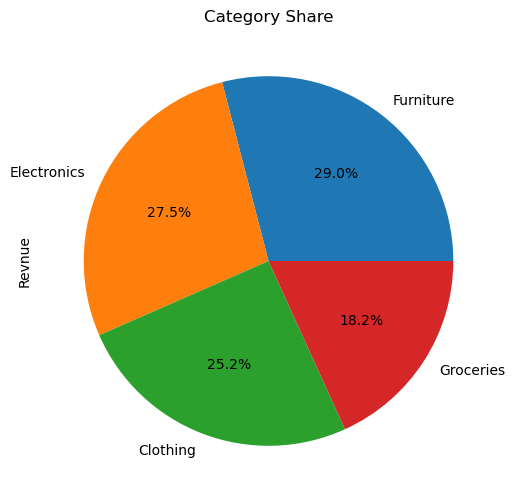

In [10]:
## Data Visualizations
import matplotlib.pyplot as plt
# Bar chart - Revenue By Region 
region_sales.plot(kind="bar", figsize=(8,5), title="Revenue by region")
plt.ylabel("Revenue")
plt.show()

# Bar chart - Top Categories
category_sales.plot(kind="bar", figsize=(8,5), color="skyblue", title="Revenue by category")
plt.ylabel("Revenue")
plt.show()

# Line Chart - Monthly Trend
monthly_sales.plot(kind="line", marker="o", figsize=(10,5), title="Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

category_sales.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6), title="Category Share")
plt.ylabel("Revnue")
plt.show()

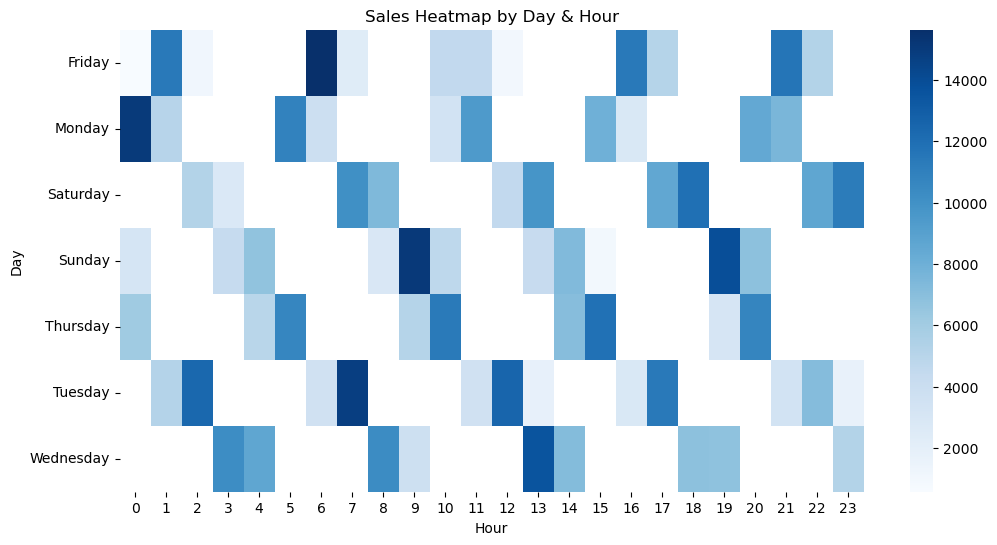

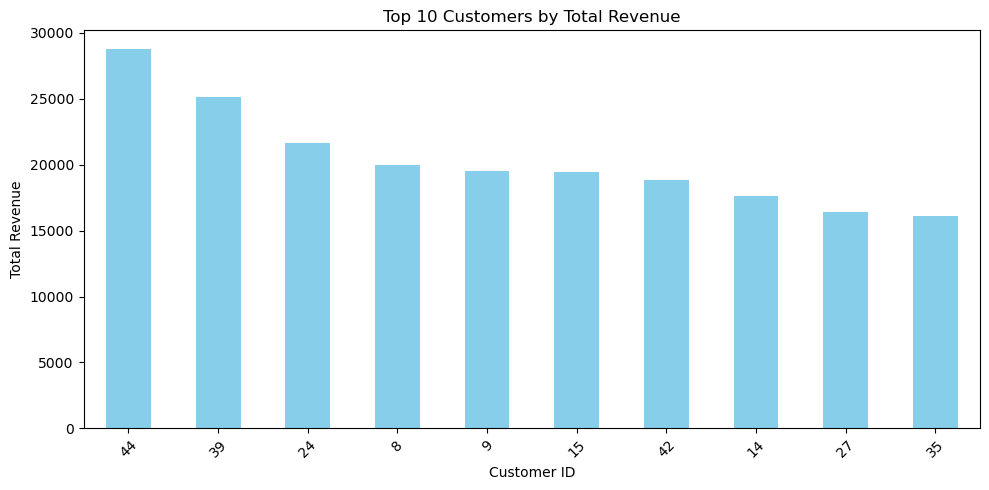

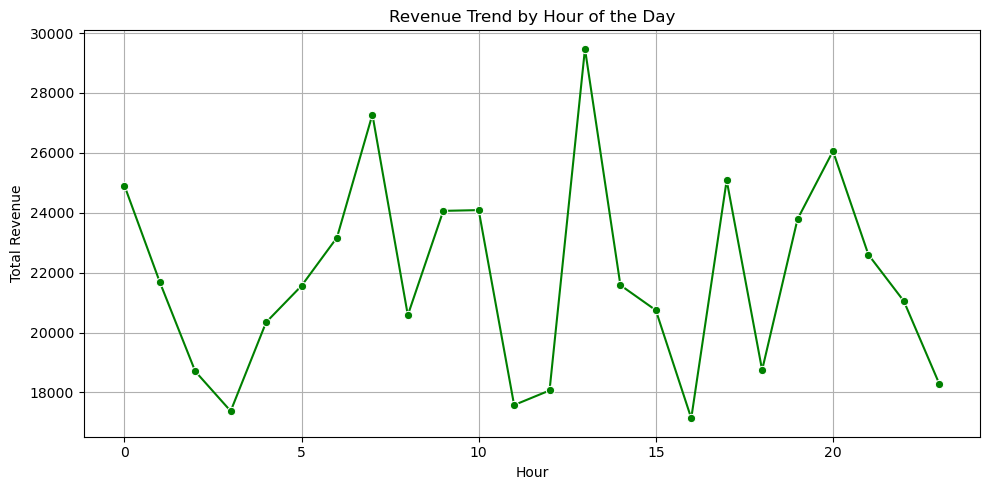

In [11]:
## Advanced Analysis
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Average order value per customer
customer_avg = df.groupby("CustomerID")["Revenue"].mean()

# Top 10 Customers
top_customers = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)

# Heatmap - Sales by Day of Week & Hour
df["Day"] = df["OrderDate"].dt.day_name()
df["Hour"] = df["OrderDate"].dt.hour

heatmap_data = df.pivot_table(values="Revenue", index="Day", columns="Hour", aggfunc="sum")
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="Blues", annot=False)
plt.title("Sales Heatmap by Day & Hour")
plt.show()

# top 10 customers by total revenue
plt.figure(figsize=(10, 5))
top_customers.head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Customers by Total Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Total Revenue by Day of the Week
hour_revenue = df.groupby("Hour")["Revenue"].sum()
plt.figure(figsize=(10, 5))
sns.lineplot(x=hour_revenue.index, y=hour_revenue.values, marker='o', color='green')
plt.title("Revenue Trend by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Total Revenue")
plt.grid(True)
plt.tight_layout()
plt.show()



In [12]:
print("Region with highest sales: ", region_sales.idxmax())
print("Best selling category: ", category_sales.idxmax())
print("Top customer revenue: ", top_customers.head(1).values[0])

Region with highest sales:  West
Best selling category:  Furniture
Top customer revenue:  28762


In [13]:
# Merge Method for data Visualization
import pandas as pd

# Load Both datasets
customers = pd.read_csv(r"C:\Users\93sha\Downloads\customers (1).csv")
orders = pd.read_csv(r"C:\Users\93sha\Downloads\orders.csv")

df = pd.merge(orders, customers, on="id", how="inner")
df

,id,order_date,ship_mode,customer_id,sales,gender,age,number_of_kids
0,115812,2014-06-09,Standard,BH-11710,3714.304,MALE,51,1
1,124478,2014-08-08,Standard,MA-17560,1109.725,MALE,32,2
2,129546,2015-09-28,Standard,RP-19855,351.916,MALE,22,0
3,153906,2015-03-16,Standard,MS-17980,85.900,FEMALE,46,4
4,162047,2015-11-03,First,FH-14365,1448.820,MALE,68,1
5,129861,2016-06-17,Standard,DM-13345,376.866,FEMALE,73,3
6,111556,2017-11-20,First,CD-11920,1559.668,FEMALE,49,4
7,121706,2017-02-26,Standard,BM-11140,356.790,MALE,24,0
8,131695,2017-06-30,Standard,RA-19285,270.800,MALE,48,1
9,146367,2017-08-04,Standard,HM-14860,3.318,MALE,61,1


In [14]:
## Pivot table creation
pivot1 = df.pivot_table(values="sales", index="age", columns="order_date", aggfunc="sum", fill_value=0)
pivot1

order_date,2014-06-09,2014-08-08,2015-03-16,2015-09-28,2015-11-03,2016-06-17,2016-07-17,2016-12-27,2017-02-20,2017-02-26,2017-06-30,2017-07-15,2017-08-04,2017-11-20
age,,,,,,,,,,,,,,
22,0.000,0.000,0.0,351.916,0.00,0.000,0.0,0.000,0.00,0.00,0.0,0.000,0.000,0.000
24,0.000,0.000,0.0,0.000,0.00,0.000,0.0,0.000,0.00,356.79,0.0,0.000,0.000,0.000
30,0.000,0.000,0.0,0.000,0.00,0.000,0.0,0.000,0.00,0.00,0.0,729.396,0.000,0.000
32,0.000,1109.725,0.0,0.000,0.00,0.000,0.0,0.000,0.00,0.00,0.0,0.000,0.000,0.000
33,0.000,0.000,0.0,0.000,0.00,0.000,656.4,0.000,0.00,0.00,0.0,0.000,0.000,0.000
35,0.000,0.000,0.0,0.000,0.00,0.000,0.0,845.488,0.00,0.00,0.0,0.000,0.000,0.000
46,0.000,0.000,85.9,0.000,0.00,0.000,0.0,0.000,19.67,0.00,0.0,0.000,0.000,0.000
48,0.000,0.000,0.0,0.000,0.00,0.000,0.0,0.000,0.00,0.00,270.8,0.000,0.000,0.000
49,0.000,0.000,0.0,0.000,0.00,0.000,0.0,0.000,0.00,0.00,0.0,0.000,0.000,1559.668
